In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import shapely
import numpy as np
import fiona

# packages from princeton gerrymetrics project
# github source: https://github.com/PrincetonUniversity/gerrymandertests
import gerrymetrics as g
import IPython.display as ipd
from collections import defaultdict

%matplotlib inline
%config InlineBackend.figure_format = "retina"

# states whos districting map changes 118-119: Alabama, Georgia, Louisiana, New York, and North Carolina

In [2]:
# congressional district boundaries cong116 data set: https://www.census.gov/geographies/mapping-files/2018/geo/carto-boundary-file.html
dists_map = gpd.read_file("data_2018/cb_2018_us_cd116_500k.shp", engine="fiona")

In [99]:
# functions to compute and plot convex hull
# input state, district number
def comp_hull(state, d):
    dist = dists_map[(dists_map["State"] == state) & (dists_map["District"] == d)]
    hull = dist.convex_hull
    return(hull)

# compute region of convex hull outside of the district
def hull_overlap(state, d):
    dist = dists_map[(dists_map["State"] == state) & (dists_map["District"] == d)]
    hull = dist.convex_hull
    overlap = hull.difference(dist)
    return(overlap)

# compute region of convex hull outside of district but within state lines
def hull_intersection(state, d):
    state_plot = dists_map[dists_map["State"] == state]
    hull = hull_overlap(state, d)
    hull_df = gpd.GeoDataFrame(geometry = hull)
    intersection = gpd.overlay(state_plot, hull_df, how="intersection", keep_geom_type = True)
    return(intersection)

# compute area of convex hull outside of district but within state lines
def hull_area(state, d):
    hull_pts = hull_intersection(state, d)
    hull = sum(hull_pts.geometry.to_crs("epsg:32633").area)
    return(hull)

# compute all hull areas
hull_areas = []
for i in range(0, len(dists_map)):
    state = dists_map["State"].iloc[i]
    d = dists_map["District"].iloc[i]
    hull = hull_area(state, d)
    hull_areas.append(hull)

# compute ratio of area of convex hull outside of district but within state lines to area of district
# idea: higher ratio implies that the district is less convex
# this func
def hull_ratio(state, d):
    dist = dists_map[(dists_map["State"] == state) & (dists_map["District"] == d)]["Area"]
    hull = hull_area(state, d)
    ratio = hull / dist
    return(ratio)

In [100]:
hull_areas("ME")

2

In [117]:
# fips to state abbreviations
fips_to_state = {
    "01": "AL", "02": "AK", "04": "AZ", "05": "AR", "06": "CA",
    "08": "CO", "09": "CT", "10": "DE", "11": "DC", "12": "FL",
    "13": "GA", "15": "HI", "16": "ID", "17": "IL", "18": "IN",
    "19": "IA", "20": "KS", "21": "KY", "22": "LA", "23": "ME",
    "24": "MD", "25": "MA", "26": "MI", "27": "MN", "28": "MS",
    "29": "MO", "30": "MT", "31": "NE", "32": "NV", "33": "NH",
    "34": "NJ", "35": "NM", "36": "NY", "37": "NC", "38": "ND",
    "39": "OH", "40": "OK", "41": "OR", "42": "PA", "44": "RI",
    "45": "SC", "46": "SD", "47": "TN", "48": "TX", "49": "UT",
    "50": "VT", "51": "VA", "53": "WA", "54": "WV", "55": "WI",
    "56": "WY"
}

dists_map["State"] = dists_map["STATEFP"].map(fips_to_state)
dists_map["District"] = list(map(lambda s: s.lstrip("0"), dists_map["CD116FP"]))
dists_map["geom_crs"] = dists_map["geometry"].geometry.to_crs("epsg:32633")
dists_map["Area"] = dists_map["geom_crs"].area
dists_map["hull_area"] = hull_areas
dists_map["Ratio"] = dists_map["hull_area"] / dists_map["Area"]

[752039857.5618254, 18587424789.1278, 4614099160.962648, 994056407.3058038, 623712717.0560752, 1288808418.199188, 1585159563.018717, 12694692820.683506, 3991525213.198993, 8772765536.469364, 1241017325.4034517, 8254675178.164867, 55453721364.056076, 722981288.8930229, 695541864.9193269, 1313191626.646243, 3934732613.0762186, 6810942357.147514, 3396733271.398777, 1093589850.40805, 158188264.4685777, 890299505.8610282, 12753441951.051369, 9525968410.329725, 849968284.3564984, 4695092191.152313, 437372800.9307713, 133658994.05956928, 3297923719.7174935, 1961302090.0413573, 38274296240.22784, 23042925574.451992, 1901177519.887901, 359151789.853506, 9855747695.030102, 33812041395.651886, 695688992.325645, 140386887.03130308, 49878310526.64365, 356157134.2753699, 201633074.31885198, 54963469638.598045, 13615461712.522177, 3286280144.049832, 8139095261.09643, 12943902262.95818, 1762584805.630246, 59945271129.26112, 1461995987.8510776, 914871780.223095, 5005534920.055795, 1140487397.7081027, 3

In [119]:
dists_map.sort_values(by = "Ratio")

,STATEFP,CD116FP,AFFGEOID,GEOID,LSAD,CDSESSN,ALAND,AWATER,geometry,State,District,geom_crs,Area,hull_area,Ratio
268,46,00,5001600US4600,4600,C1,116,196346981786,3382720225,"POLYGON ((-104.05788 44.9976, -104.05078 44.99...",SD,,"POLYGON ((-4110042.974 12883379.401, -4110462....",3.423557e+11,0.000000e+00,0.000000
296,02,00,5001600US0200,0200,C1,116,1478839695958,245481577452,"MULTIPOLYGON (((179.48246 51.98283, 179.48656 ...",AK,,"MULTIPOLYGON (((1562410.901 14122223.28, 15621...",1.543564e+12,0.000000e+00,0.000000
335,72,98,5001600US7298,7298,C3,116,8868896030,4922382562,"MULTIPOLYGON (((-65.23805 18.32167, -65.23467 ...",NaN,98,"MULTIPOLYGON (((-10312248.861 7032399.189, -10...",7.451035e+10,0.000000e+00,0.000000
241,78,98,5001600US7898,7898,C4,116,348021896,1550236201,"MULTIPOLYGON (((-64.62799 17.78933, -64.62717 ...",NaN,98,"MULTIPOLYGON (((-10369954.353 6793583.977, -10...",2.816607e+09,0.000000e+00,0.000000
276,69,98,5001600US6998,6998,C4,116,472292529,4644252461,"MULTIPOLYGON (((146.05103 16.00674, 146.05167 ...",NaN,98,"MULTIPOLYGON (((6358213.752 17377629.003, 6358...",1.027964e+09,0.000000e+00,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
178,17,04,5001600US1704,1704,C2,116,135804048,966145,"POLYGON ((-87.92062 41.88975, -87.92057 41.897...",IL,4,"POLYGON ((-5366208.969 11554970.143, -5365058....",2.882563e+08,3.986908e+08,1.383113
6,26,14,5001600US2614,2614,C2,116,480339355,97940449,"POLYGON ((-83.43929 42.56014, -83.43626 42.562...",MI,14,"POLYGON ((-5406712.17 11007935.08, -5406398.20...",1.067566e+09,1.585160e+09,1.484836
194,22,02,5001600US2202,2202,C2,116,3285174126,522407749,"POLYGON ((-91.32548 30.34681, -91.31954 30.343...",LA,2,"POLYGON ((-7036542.661 12841428.217, -7037547....",1.239493e+10,1.954778e+10,1.577079
109,48,35,5001600US4835,4835,C2,116,1538273012,19151538,"POLYGON ((-98.54734 29.44272, -98.5437 29.4423...",TX,35,"POLYGON ((-6478012.226 13915657.866, -6478450....",4.287454e+09,7.461464e+09,1.740302


<Axes: >

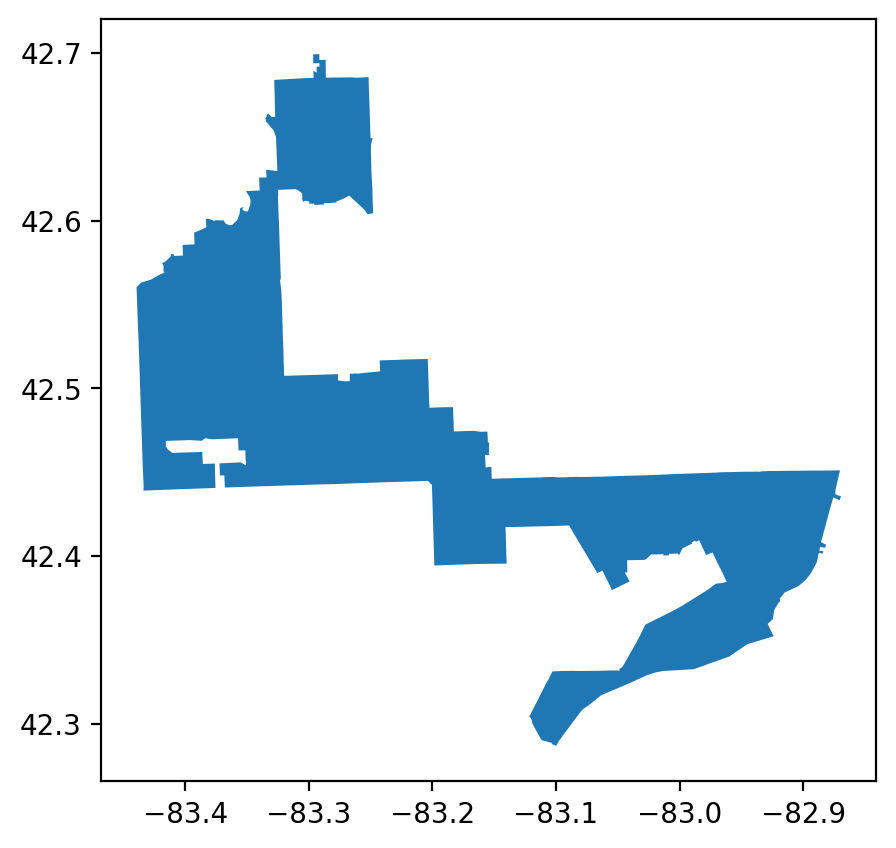

In [123]:
dists_map[(dists_map["State"] == "MI") & (dists_map["District"] == "14")].plot(figsize = (5,5))